<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/MNIST_simples_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Text_classification_with_CNN_Prática

In [24]:
# bibliotecas
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [26]:
df = pd.read_csv("wow_text.csv")

In [27]:
# lê o CSV com para evitar erro de caracteres
df = pd.read_csv("wow_text.csv")
# mostra as 5 primeiras linhas do dataframe
df.head()

,label,text
0,positivo,finalmente dropei a mount rara slk bom dms
1,negativo,wipe no primeiro boss q odio mano
2,positivo,monk ww ta mt forte no pvp
3,negativo,40 min fila arena pra nada aff
4,positivo,peguei gear top na mythic+ hj


In [28]:
df.columns = ['Positivo/negativo', 'dados']
df.head()

,Positivo/negativo,dados
0,positivo,finalmente dropei a mount rara slk bom dms
1,negativo,wipe no primeiro boss q odio mano
2,positivo,monk ww ta mt forte no pvp
3,negativo,40 min fila arena pra nada aff
4,positivo,peguei gear top na mythic+ hj


In [29]:
# mapeando
df['target'] = df['Positivo/negativo'].map({'positivo': 1, 'negativo': 0})
Y = df['target'].values

In [30]:
# treino e teste
df_train, df_test, Ytrain, Ytest = train_test_split(df['dados'], Y, test_size=0.33)

In [31]:
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)

sequencias_train = tokenizer.texts_to_sequences(df_train)
sequencias_test = tokenizer.texts_to_sequences(df_test)

In [32]:
T = 15 # Definindo o tamanho máximo
Xtrain = pad_sequences(sequencias_train, maxlen=T)
Xtest = pad_sequences(sequencias_test, maxlen=T)
V = len(tokenizer.word_index)

In [33]:
D = 20 # Dimensão do embedding
i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [34]:
# compilação e Treino
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [35]:
r = model.fit(
    Xtrain, Ytrain,
    epochs=20,
    validation_data=(Xtest, Ytest)
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8000 - loss: 0.6912 - val_accuracy: 0.3333 - val_loss: 0.6957
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6000 - loss: 0.6854 - val_accuracy: 0.3333 - val_loss: 0.6978
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6000 - loss: 0.6805 - val_accuracy: 0.3333 - val_loss: 0.6999
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6000 - loss: 0.6760 - val_accuracy: 0.3333 - val_loss: 0.7018
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6718 - val_accuracy: 0.3333 - val_loss: 0.7038
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6000 - loss: 0.6676 - val_accuracy: 0.3333 - val_loss: 0.7058
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6000 - loss: 0.6633 - val_accuracy: 0.3333 - val_loss: 0.7076
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6000 - loss: 0.6592 - val_accuracy: 0.3333 - val_loss: 0.7094


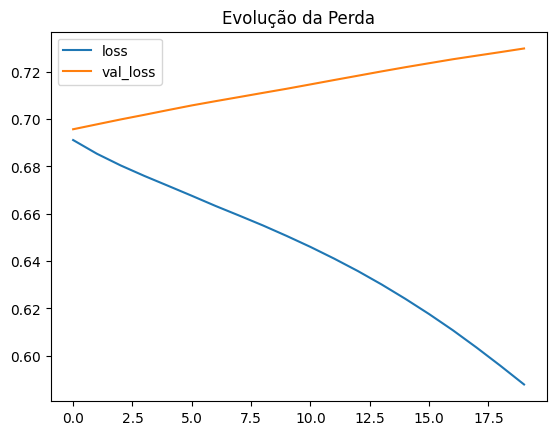

In [36]:
# visualização dos Resultados
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.title("Evolução da Perda")
plt.legend()
plt.show()

## Text_preprocessing_Pratica

In [37]:
# bilbioteca
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [38]:
# configurando
MAX_VOCAB = 20000 # tamanho maximo
MAX_LEN = 6

In [39]:
# definindo dados de exemplo
sentencias= [
    "To upando um monge WW pra brincar no PvP",
    "DK profano parece muito quebrado na arena",
    "Preciso aprender a dar kite melhor contra melee",
    "Battleground ranqueada deve ser uma loucura no WoW"
]

In [40]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(sentencias)
sequencias = tokenizer.texts_to_sequences(sentencias)
data = pad_sequences(sequencias, maxlen=6)

In [41]:
# transformando em sequências numéricas
sequencias = tokenizer.texts_to_sequences(sentencias)
print(sequencias)

[[3, 4, 5, 6, 7, 8, 9, 2, 10], [11, 12, 13, 14, 15, 16, 17], [18, 19, 20, 21, 22, 23, 24, 25], [26, 27, 28, 29, 30, 31, 2, 32]]


In [42]:
tokenizer.word_index # Mostra o índice de cada palavra

{'<OOV>': 1,
 'no': 2,
 'to': 3,
 'upando': 4,
 'um': 5,
 'monge': 6,
 'ww': 7,
 'pra': 8,
 'brincar': 9,
 'pvp': 10,
 'dk': 11,
 'profano': 12,
 'parece': 13,
 'muito': 14,
 'quebrado': 15,
 'na': 16,
 'arena': 17,
 'preciso': 18,
 'aprender': 19,
 'a': 20,
 'dar': 21,
 'kite': 22,
 'melhor': 23,
 'contra': 24,
 'melee': 25,
 'battleground': 26,
 'ranqueada': 27,
 'deve': 28,
 'ser': 29,
 'uma': 30,
 'loucura': 31,
 'wow': 32}

In [44]:
data = pad_sequences(sequencias) # realiza o padding das sequências
print(data)

[[ 3  4  5  6  7  8  9  2 10]
 [ 0  0 11 12 13 14 15 16 17]
 [ 0 18 19 20 21 22 23 24 25]
 [ 0 26 27 28 29 30 31  2 32]]


In [45]:
MAX_SEQUENCE_LENGTH = 5 # limitando para 5 palavras
data = pad_sequences(sequencias, maxlen=MAX_SEQUENCE_LENGTH)
print(data)

[[ 7  8  9  2 10]
 [13 14 15 16 17]
 [21 22 23 24 25]
 [29 30 31  2 32]]


In [46]:
data = pad_sequences(sequencias, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
print(data)

[[ 7  8  9  2 10]
 [13 14 15 16 17]
 [21 22 23 24 25]
 [29 30 31  2 32]]


In [47]:
data = pad_sequences(sequencias, maxlen=6) # padding com 6 de tamanho
print(data)

[[ 6  7  8  9  2 10]
 [12 13 14 15 16 17]
 [20 21 22 23 24 25]
 [28 29 30 31  2 32]]


In [48]:
data = pad_sequences(sequencias, maxlen=4) # Diminui o tamanho da sequência
print(data)

[[ 8  9  2 10]
 [14 15 16 17]
 [22 23 24 25]
 [30 31  2 32]]


In [49]:
data = pad_sequences(sequencias, maxlen=4, truncating='post')
print(data)

[[ 3  4  5  6]
 [11 12 13 14]
 [18 19 20 21]
 [26 27 28 29]]
